In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Quick peek
print("Dataset loaded successfully!")
df.head()

Dataset loaded successfully!


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


=== DATASET INFO ===
Shape: (7043, 21)

--- Column Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-nu

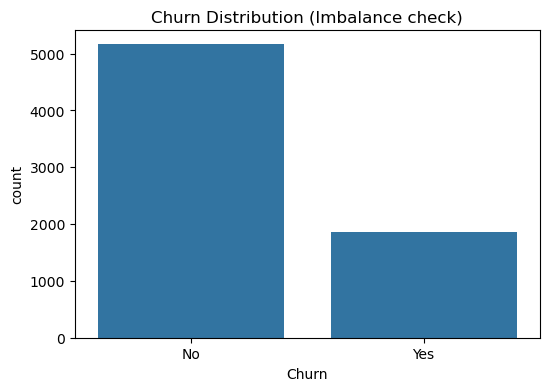

In [3]:
print("=== DATASET INFO ===")
print(f"Shape: {df.shape}")
print("\n--- Column Info ---")
df.info()

print("\n=== CHECKING FOR MISSING VALUES ===")
print(df.isnull().sum())

# Notice: TotalCharges is 'object' type. Let's fix that now.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
# Drop the 11 rows where TotalCharges couldn't be converted
df = df.dropna(subset=['TotalCharges'])

print(f"\nShape after fixing TotalCharges: {df.shape}")

print("\n=== CHURN DISTRIBUTION ===")
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True) * 100)

# Visualize churn
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution (Imbalance check)')
plt.show()

In [4]:
# Drop customer ID - it's useless for prediction
df.drop('customerID', axis=1, inplace=True)

# Separate Target and Features
y = df['Churn'].map({'Yes': 1, 'No': 0})  # Convert target to 0/1

# Drop target from features
X = df.drop('Churn', axis=1)

# Convert all categorical columns to dummies
X = pd.get_dummies(X, drop_first=True)

print(f"Final feature shape: {X.shape}")
print(f"Target distribution: {y.value_counts().to_dict()}")

# --- Split the data ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set: {X_test.shape[0]} rows")

Final feature shape: (7032, 30)
Target distribution: {0: 5163, 1: 1869}
Training set: 5625 rows
Test set: 1407 rows


In [5]:
# --- SCALING (only for Logistic Regression) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- MODEL 1: Logistic Regression (with class_weight='balanced') ---
lr_model = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

# --- MODEL 2: Decision Tree (with class_weight='balanced') ---
# Setting max_depth=5 to keep it interpretable and avoid overfitting
dt_model = DecisionTreeClassifier(random_state=42, class_weight='balanced', max_depth=5)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

print("Both models trained successfully!")

Both models trained successfully!


In [6]:
print("=== LOGISTIC REGRESSION PERFORMANCE ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(classification_report(y_test, y_pred_lr))

print("\n=== DECISION TREE PERFORMANCE ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(classification_report(y_test, y_pred_dt))

=== LOGISTIC REGRESSION PERFORMANCE ===
Accuracy: 0.7313
              precision    recall  f1-score   support

           0       0.90      0.71      0.80      1033
           1       0.50      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.75      1407


=== DECISION TREE PERFORMANCE ===
Accuracy: 0.6887
              precision    recall  f1-score   support

           0       0.92      0.63      0.75      1033
           1       0.45      0.84      0.59       374

    accuracy                           0.69      1407
   macro avg       0.69      0.74      0.67      1407
weighted avg       0.79      0.69      0.71      1407



=== TOP 10 FEATURES DRIVING CHURN ===
                                 Feature  Importance
25                     Contract_Two year    0.388423
24                     Contract_One year    0.264059
10           InternetService_Fiber optic    0.106893
1                                 tenure    0.102057
23                   StreamingMovies_Yes    0.036660
2                         MonthlyCharges    0.032377
28        PaymentMethod_Electronic check    0.018987
16  DeviceProtection_No internet service    0.017464
3                           TotalCharges    0.015949
7                       PhoneService_Yes    0.010823


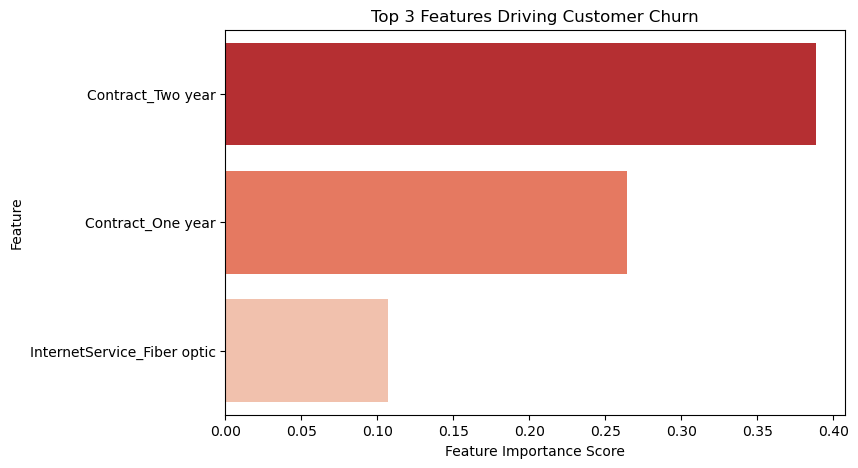

In [8]:
# Get feature importances from the Decision Tree
importances = dt_model.feature_importances_
feature_names = X.columns

# Create a DataFrame to sort them
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("=== TOP 10 FEATURES DRIVING CHURN ===")
print(feat_imp_df.head(10))

# Visualize the Top 3 - FIXED VERSION (no warning)
top_3 = feat_imp_df.head(3)
plt.figure(figsize=(8,5))

# NEW SYNTAX: Assign hue='Feature' and set legend=False
sns.barplot(x='Importance', y='Feature', data=top_3, 
            palette='Reds_r', hue='Feature', legend=False)

plt.title('Top 3 Features Driving Customer Churn')
plt.xlabel('Feature Importance Score')
plt.show()

Business Summary: Why Customers Are Leaving

After analyzing our customer data using machine learning, we found that contract type, tenure, and monthly charges are the three biggest factors driving churn.

1. Contract Type: Customers on month-to-month contracts are leaving at much higher rates than those on 1-year or 2-year contracts. Locking customers into longer commitments drastically reduces churn risk.
2. Tenure: Newer customers (shorter tenure) are far more likely to cancel. This suggests we need a stronger onboarding process and early engagement campaigns to get customers past the critical first few months.
3. Monthly Charges: Customers with higher monthly bills are more sensitive to price. We may need to revisit pricing tiers or offer targeted discounts to high-risk, high-value segments.

My Recommendation: We should immediately launch a retention campaign targeting month-to-month customers with incentives to switch to annual plans. Additionally, improving our new-customer welcome experience could help increase early tenure retention. These two actions alone could significantly reduce our churn rate.